
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [1]:
import copy
import inspect
import json
import math
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [2]:
# Data and target settings
DATASET_NAME = "mean_curvature_smooth"
TARGET_INDICES = [0]
USE_GLOBAL_FEATURES = True

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and scan settings
VAL_FRAC = 0.2
SPLIT_SEED = None
FORCED_VAL_KEYS = set()
K_MAX = 4
NUM_LAYERS_LIST = [1, 2, 4]
HIDDEN_DIMS = [16, 32, 64, 2 * 64, 3 * 64, 4 * 64, 6 * 64, 8 * 64]

# Model settings
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4

# Experiment output settings
EXPERIMENT_GROUP = "model_size_scan"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"


In [3]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def ensure_figure_dir():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    return FIGURES_DIR


def save_mpl_figure(fig, name, *, close=False):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.pdf"
    fig.savefig(path, bbox_inches="tight", transparent=True)
    print(f"Saved figure -> {path}")
    if close:
        plt.close(fig)
    return path

In [4]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers.")

print_graph_and_metadata_fields(graphs)


Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers.
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [ ]:
# Optional day3p5 timepoint filter
from src.data.filters import filter_graphs_by_metadata

DAY3P5_TIMEPOINT = "day3p5"

# Default: remove day3p5 graphs if present.
graphs = filter_graphs_by_metadata(
    graphs,
    key="timepoint",
    drop_values={DAY3P5_TIMEPOINT},
    missing="keep",
    inplace=False,
    print_summary=True,
)

# Alternative: keep only day3p5 graphs and filter out all other timepoints.
# Uncomment this block and comment out the default block above if needed.
# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     keep_values={DAY3P5_TIMEPOINT},
#     missing="drop",
#     inplace=False,
#     print_summary=True,
# )


In [5]:
# Optional categorical metadata filters can be added here.


In [6]:
from src.data.metadata import fill_missing_metadata_for_group
from src.data.filters import (
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


filter_graphs_by_sphericity(max_sphericity=0.92): kept 819 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                244    342    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         290    411    0.706
20251201         day4p5              196    277    0.708
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 37     98    0.378
20250929         day4p5                9     15    0.600
20250929         day4p5-more          27    121    0.223
20251201         day4p5               20     81    0.247
filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 712 / 819 graphs

dataset          timepoint          kept  total

In [7]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


In [8]:
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)


Split -> train: 644 | val: 161
global_dim = 4


In [9]:
print("target_transform =", target_transform.name)


target_transform = asinh_standardize


In [10]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")


In [11]:
from src.data.ring_features import attach_precomputed_ring_features

g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)


In [12]:
from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP
from src.training.loop import train
from src.data.metadata import infer_global_dim

num_layers_list = NUM_LAYERS_LIST
hidden_dims = HIDDEN_DIMS

trained_models = {}

for k in num_layers_list:
    family_name = f"GIN_L{k}"
    trained_models[family_name] = []

    for h in hidden_dims:
        print(f"\n=== Training {family_name} with hidden_dim={h} ===")

        model_kwargs = {
            "n_markers": int(g_train[0].x.size(1)),
            "global_dim": infer_global_dim(g_train),
            "hidden_dim": int(h),
            "num_layers": int(k),
            "dropout": DROPOUT,
            "residual": RESIDUAL,
            "norm": NORM,
            "train_eps": True,
        }

        model = GINCurvature(**model_kwargs)

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_models[family_name].append(model)


for k in num_layers_list:
    family_name = f"ring_L{k}"
    trained_models[family_name] = []

    for h in hidden_dims:
        print(f"\n=== Training {family_name} with hidden_dim={h} ===")     

        model_kwargs = {
            "n_markers": int(g_train[0].x.size(1)),
            "global_dim": infer_global_dim(g_train),
            "k_hops": int(k),
            "hidden_dim": int(h),
            "dropout": DROPOUT,
            "norm": NORM,
            "feature_attr": "x_ring",
        }

        model = RingFractionMLP(**model_kwargs)

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_models[family_name].append(model)



=== Training GIN_L1 with hidden_dim=16 ===
epoch 001 | train loss 0.5365 mae 0.8127 | val loss 0.4945 mae 0.7910
epoch 002 | train loss 0.5276 mae 0.8070 | val loss 0.4897 mae 0.7874
epoch 003 | train loss 0.5201 mae 0.8021 | val loss 0.4846 mae 0.7836
epoch 004 | train loss 0.5132 mae 0.7975 | val loss 0.4785 mae 0.7790
epoch 005 | train loss 0.5069 mae 0.7931 | val loss 0.4722 mae 0.7741
epoch 006 | train loss 0.5014 mae 0.7892 | val loss 0.4659 mae 0.7686
epoch 007 | train loss 0.4966 mae 0.7855 | val loss 0.4598 mae 0.7632
epoch 008 | train loss 0.4921 mae 0.7820 | val loss 0.4546 mae 0.7585
epoch 009 | train loss 0.4884 mae 0.7789 | val loss 0.4500 mae 0.7543
epoch 010 | train loss 0.4841 mae 0.7757 | val loss 0.4458 mae 0.7508
epoch 011 | train loss 0.4807 mae 0.7730 | val loss 0.4419 mae 0.7474
epoch 012 | train loss 0.4773 mae 0.7708 | val loss 0.4386 mae 0.7445
epoch 013 | train loss 0.4738 mae 0.7684 | val loss 0.4368 mae 0.7442
epoch 014 | train loss 0.4708 mae 0.7662 | val

In [13]:
from src.analysis.prediction_analysis import eval_model_per_marker

def evaluate_family_models(trained_models, eval_subgraphs, device, target_transform):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        # aggregate storage
        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_marker(
                model,
                eval_subgraphs,
                device=device,
                target_transform=target_transform,
                center_only=False,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        # stack aggregate arrays across model depth / family member index
        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                vals = fam_aggregate[agg_name][metric]
                fam_aggregate_stacked[agg_name][metric] = np.asarray(vals, dtype=float)

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results


eval_results = evaluate_family_models(
    trained_models=trained_models,
    eval_subgraphs=g_val,
    device=device,
    target_transform=target_transform,
)

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_20260506_101251/figures/markerwise_mse_by_hidden_dim.pdf


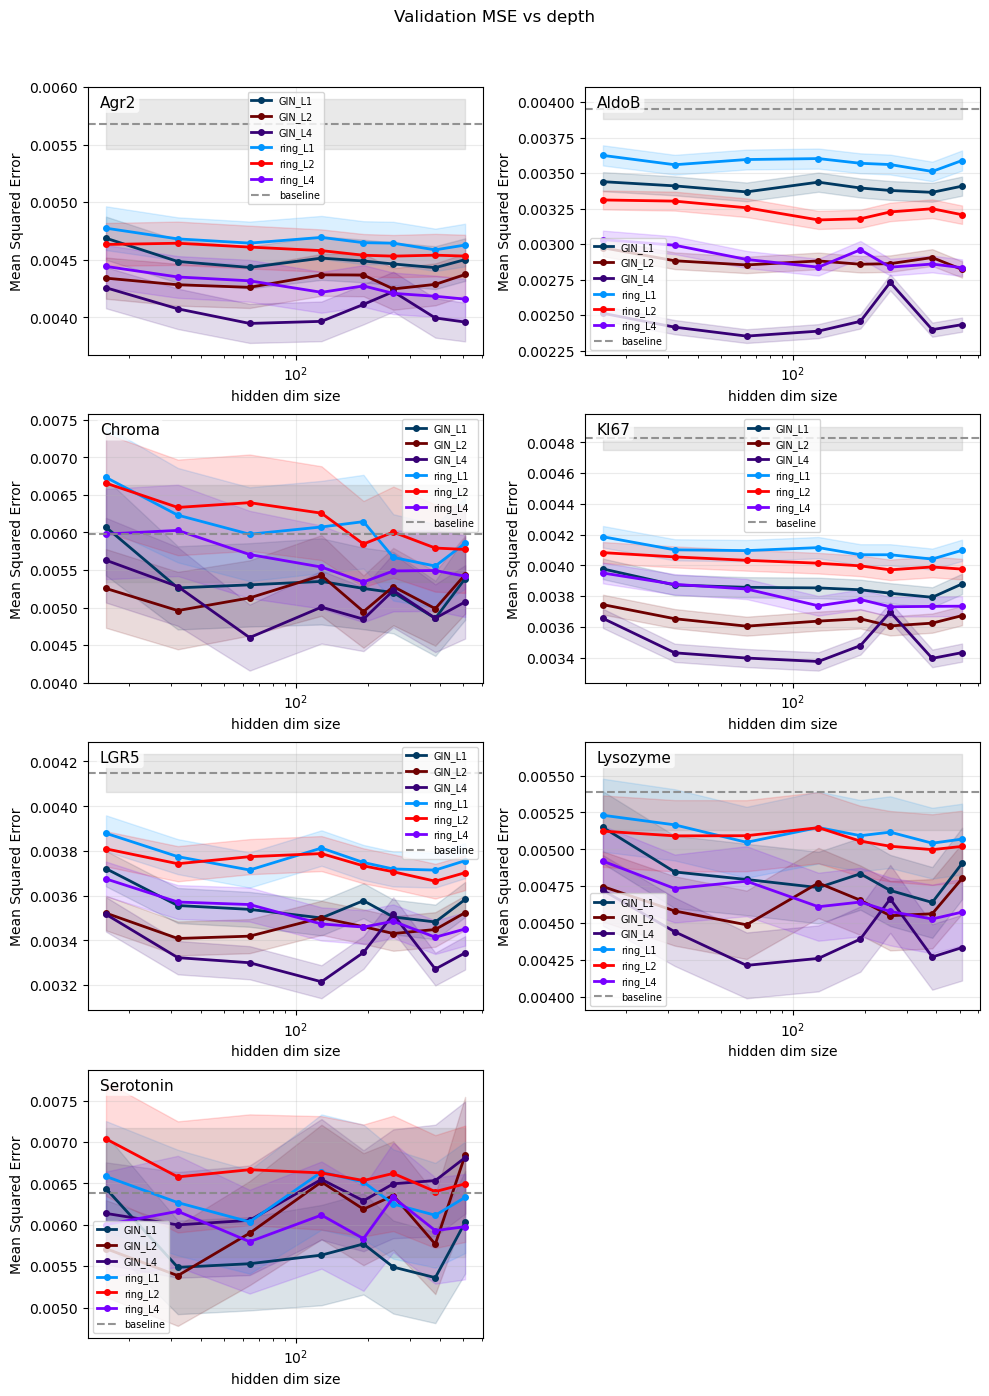

In [17]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GIN_L1": "#003961",
    "GIN_L2": "#6e0000",
    "GIN_L4": "#370075",
    "ring_L1": "#0095ff",
    "ring_L2": "#ff0000",
    "ring_L4": "#7700ff",
}


family_order = [
    "GIN_L1",
    "GIN_L2",
    "GIN_L4",
    "ring_L1",
    "ring_L2",
    "ring_L4",
]


fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=hidden_dims,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)

# modify afterwards
for ax in axes:
    ax.set_xticks(hidden_dims)
    ax.set_xticklabels([f"{v}" for v in hidden_dims])
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

save_mpl_figure(fig, "markerwise_mse_by_hidden_dim")
plt.show()

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_20260506_101251/figures/aggregate_mse_by_hidden_dim.pdf


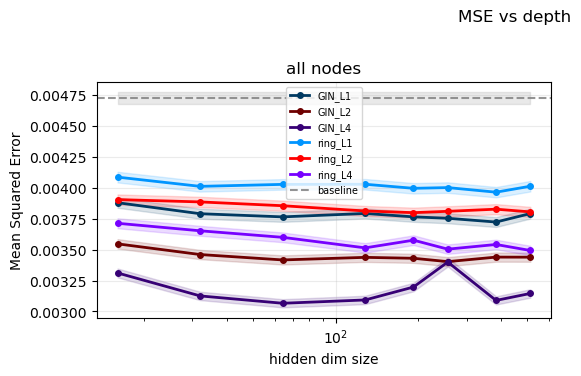

In [18]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    hidden_dims,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

save_mpl_figure(fig, "aggregate_mse_by_hidden_dim")
plt.show()

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_20260506_101251/figures/markerwise_nll_by_hidden_dim.pdf


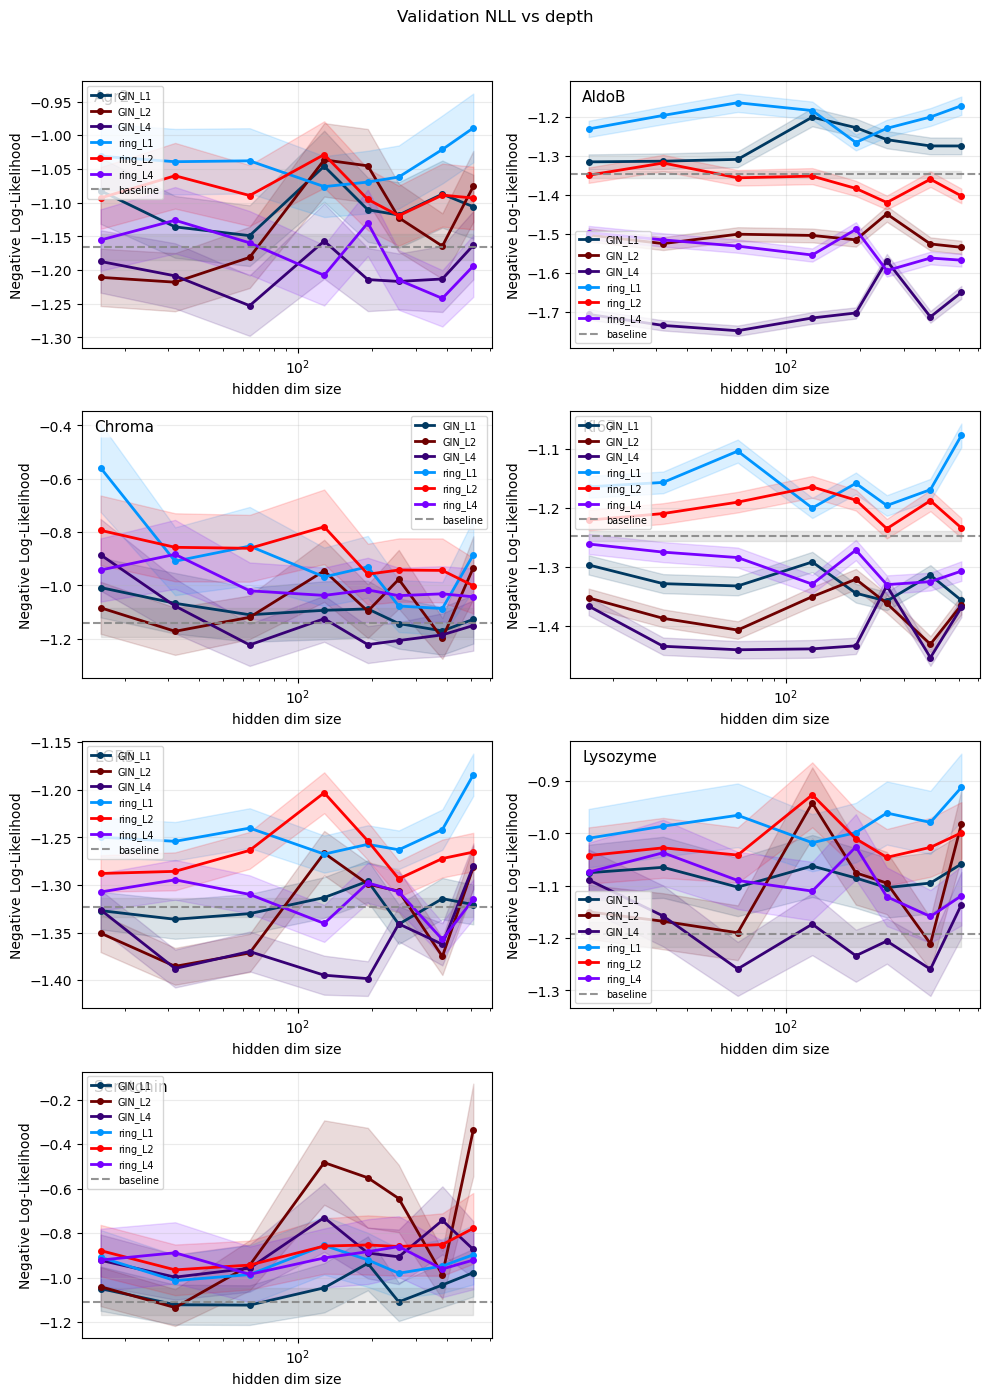

In [19]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=hidden_dims,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

save_mpl_figure(fig, "markerwise_nll_by_hidden_dim")
plt.show()

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_20260506_101251/figures/aggregate_nll_by_hidden_dim.pdf


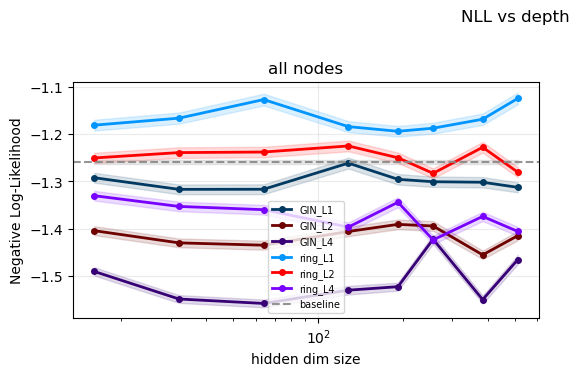

In [20]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    hidden_dims,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

save_mpl_figure(fig, "aggregate_nll_by_hidden_dim")
plt.show()

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_20260506_101251/figures/markerwise_uncertainty_error_correlation_by_hidden_dim.pdf


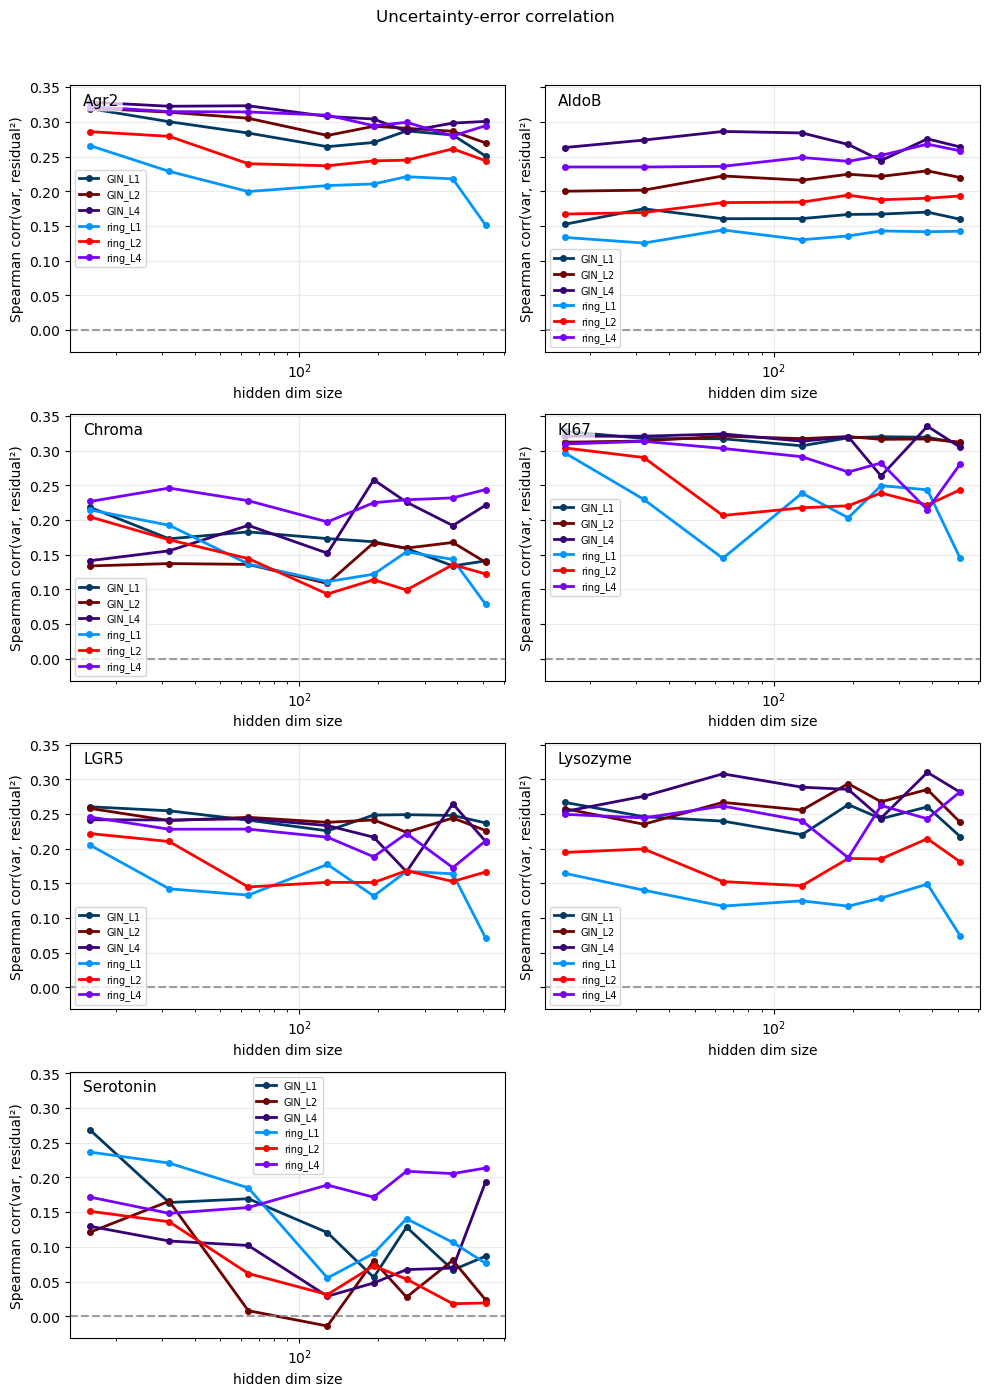

In [21]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=hidden_dims,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

save_mpl_figure(fig, "markerwise_uncertainty_error_correlation_by_hidden_dim")
plt.show()

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_20260506_101251/figures/aggregate_uncertainty_error_correlation_by_hidden_dim.pdf


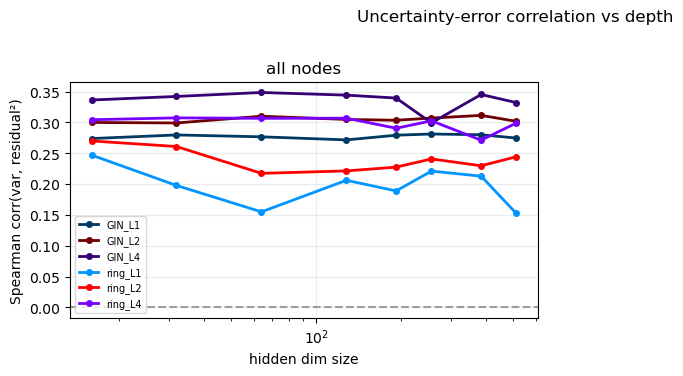

In [22]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    hidden_dims,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

save_mpl_figure(fig, "aggregate_uncertainty_error_correlation_by_hidden_dim")
plt.show()

In [23]:
def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Saved joint experiment → {save_dir}")

In [24]:
joint_config = {
    "experiment_group": "compare_models",

    "model_families": list(trained_models.keys()),
    "depths": num_layers_list,

    "hidden_dims": hidden_dims,
    "dropout": 0.1,
    "norm": "batch",

    "train_config": {
        "loss_name": cfg.loss_name,
        "lr": cfg.lr,
        "batch_size": cfg.batch_size,
        "max_epochs": cfg.max_epochs,
        "patience": cfg.patience,
        "num_workers": cfg.num_workers,
    },

    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),

    "marker_names": list(marker_names),
    "save_dir": str(SAVE_DIR),
    "figures_dir": str(FIGURES_DIR),
}

In [25]:
results_by_experiment = {
    "eval_results": eval_results,
}

save_dir = SAVE_DIR

save_joint_experiment(
    save_dir=save_dir,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes="Compare performance as function of model size for different depths",
)

Saved joint experiment → /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_20260506_101251
